In [113]:
using JLD2
using Statistics
using Printf
using Laplacians
using Plots

In [2]:
sortrows(A, i, rev=false) = sortslices(A, dims=1, lt=(x,y)->isless(x[i],y[i]), rev=rev)

sortrows (generic function with 2 methods)

# scaling of AC on unit wt chimera

In [3]:
# unweighted chimera
@load "uni_chimera_all.jl.split02merge02.n10000.h1.0.jld2"
dic_uniChimera = copy(dic);
@load "uni_chimera_all.jl.split02merge02.n100000.h2.0.jld2"
dic_uniChimera = merge(vcat,dic_uniChimera, dic);
@load "uni_chimera_all.jl.split02merge02.n1000000.h4.0.jld2"
dic_uniChimera = merge(vcat,dic_uniChimera, dic);
@load "uni_chimera_all.jl.split02merge02.n10000000.h8.0.jld2"
dic_uniChimera = merge(vcat,dic_uniChimera, dic);

In [48]:
nnz_w_time = [ dic_uniChimera["ne"] dic_uniChimera["ac_tot"] ];
sort_nnz_w_time = sortrows(nnz_w_time,1)

239×2 Matrix{Float64}:
 29998.0          0.00258589
 29998.0          0.00256562
 29998.0          0.00267982
 30336.0          0.00658798
 30828.0          0.00687885
 30978.0          0.00732589
 33150.0          0.0109189
 33216.0          0.0108397
 33222.0          0.01053
 33252.0          0.010771
 33300.0          0.0114799
 35334.0          0.0134501
 39992.0          0.018275
     ⋮          
     9.0e6       14.6511
     1.25932e7   26.3746
     1.42552e7   25.3653
     1.77297e7   26.9494
     4.00087e7  137.042
     5.01634e7  129.36
     6.55036e7  160.754
     6.61169e7  197.867
     9.83662e7  202.406
     1.01597e8  344.842
     1.12547e8  444.75
     1.22062e8  312.313

In [58]:
@show nnzmin = sort_nnz_w_time[1,1];
@show nnzmax = sort_nnz_w_time[end,1];

nnzmin = sort_nnz_w_time[1, 1] = 29998.0
nnzmax = sort_nnz_w_time[end, 1] = 1.22062482e8


Here's just a plot of t/nnz as a function of nnz (log scale on x-axis)

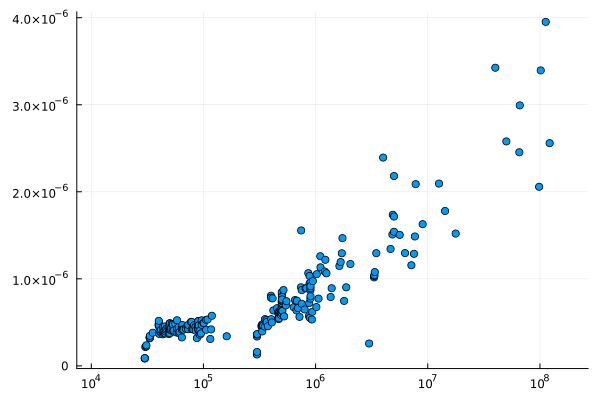

In [49]:
pdata = [ sort_nnz_w_time[:,1] sort_nnz_w_time[:,2]./sort_nnz_w_time[:,1] ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8])

If O(mlog^3m) is an upper bound, then after dividing by that, we shouldn't see growth. The following plots show this.

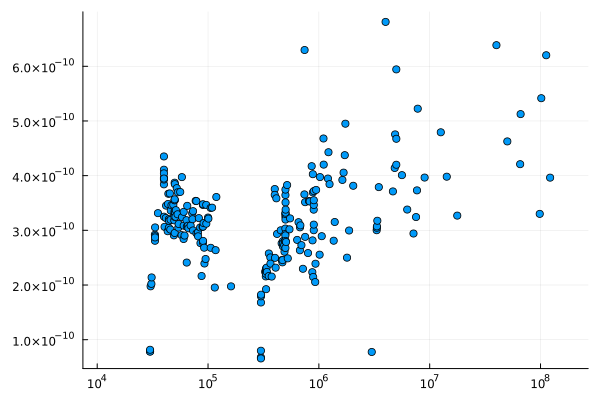

In [51]:
pdata = [ sort_nnz_w_time[:,1] sort_nnz_w_time[:,2]./((x -> x*log(x)^3).(sort_nnz_w_time[:,1])) ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8])

The simplest plot would just be nnz vs time -- but this doesn't seem that useful w/o a slope estimate

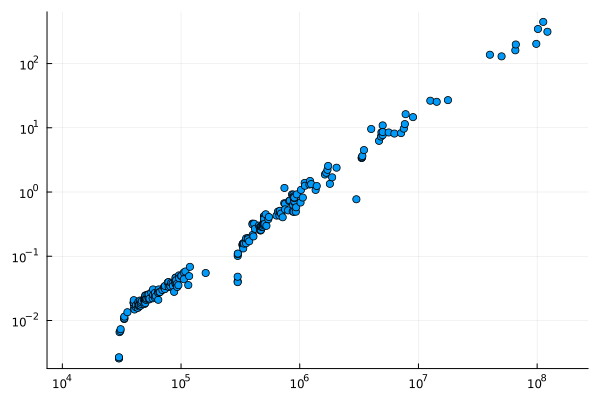

In [100]:
pdata = sort_nnz_w_time
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)

Maybe we can get a better sense of the data by adding a line for m log^3 m?

Here's m vs time and m vs 8e-9 mlog^3m

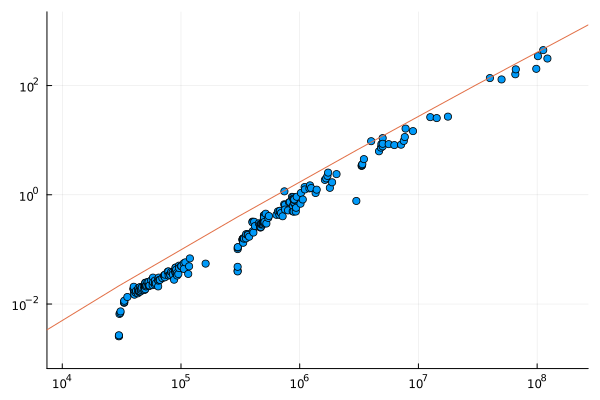

In [111]:
pdata = sort_nnz_w_time
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)

logmin = log10(nnzmin)-1
logmax = log10(nnzmax)+1
pmodelx = [10^i for i = logmin:logmax];
pmodely = [ 8e-9 * 10^i * i^3 for i = logmin:logmax];

plot!(pmodelx,pmodely,label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)



Next let's see m vs time/n and m vs 8e-9 log^3m

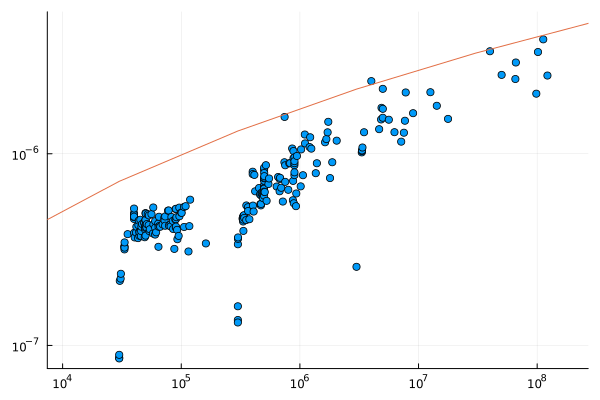

In [109]:
pdata = [ sort_nnz_w_time[:,1] sort_nnz_w_time[:,2]./sort_nnz_w_time[:,1] ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)

logmin = log10(nnzmin)-1
logmax = log10(nnzmax)+1
pmodelx = [10^i for i = logmin:logmax];
pmodely = [ 8e-9 * i^3 for i = logmin:logmax];

plot!(pmodelx,pmodely,label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)


# scaling of AC2 on unit wt chimera


In [115]:
nnz_w_time = [ dic_uniChimera["ne"] dic_uniChimera["ac2_tot"] ];
sort_nnz_w_time = sortrows(nnz_w_time,1)

239×2 Matrix{Float64}:
 29998.0           0.00374699
 29998.0           0.00379801
 29998.0           0.0039711
 30336.0           0.00867295
 30828.0           0.00901198
 30978.0           0.0100162
 33150.0           0.016144
 33216.0           0.0164962
 33222.0           0.0164521
 33252.0           0.0164089
 33300.0           0.0166278
 35334.0           0.0249898
 39992.0           0.0443261
     ⋮          
     9.0e6        58.4699
     1.25932e7   174.436
     1.42552e7   204.408
     1.77297e7   269.989
     4.00087e7   348.062
     5.01634e7   486.428
     6.55036e7   721.611
     6.61169e7   938.317
     9.83662e7   869.369
     1.01597e8  2366.71
     1.12547e8  2868.64
     1.22062e8  1312.19

Here's a plot of t/nnz as a function of nnz (log scale on x-axis)

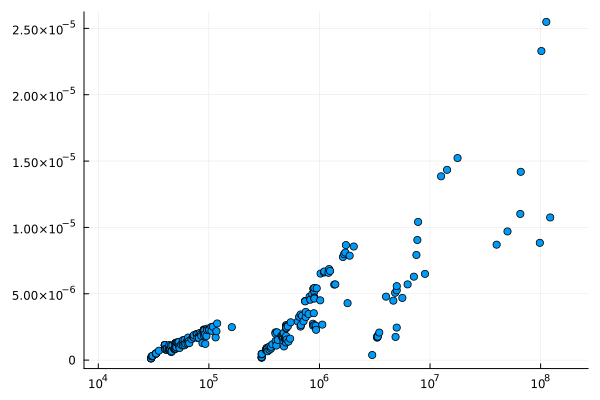

In [116]:
pdata = [ sort_nnz_w_time[:,1] sort_nnz_w_time[:,2]./sort_nnz_w_time[:,1] ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8])

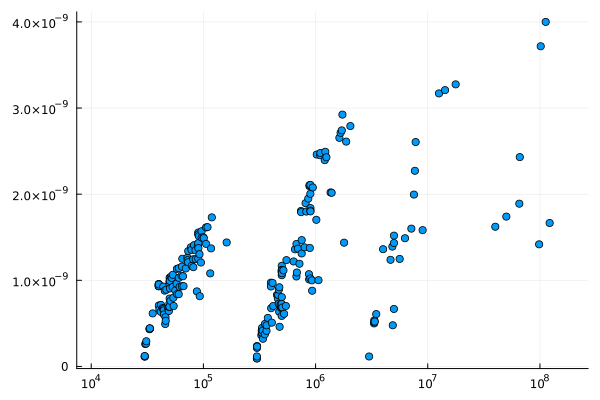

In [117]:
pdata = [ sort_nnz_w_time[:,1] sort_nnz_w_time[:,2]./((x -> x*log(x)^3).(sort_nnz_w_time[:,1])) ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8])

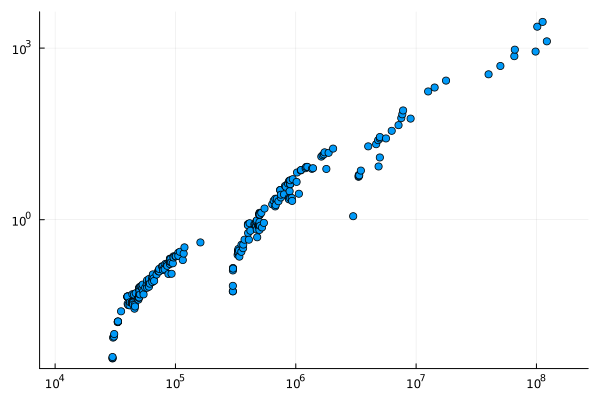

In [118]:
pdata = sort_nnz_w_time
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)

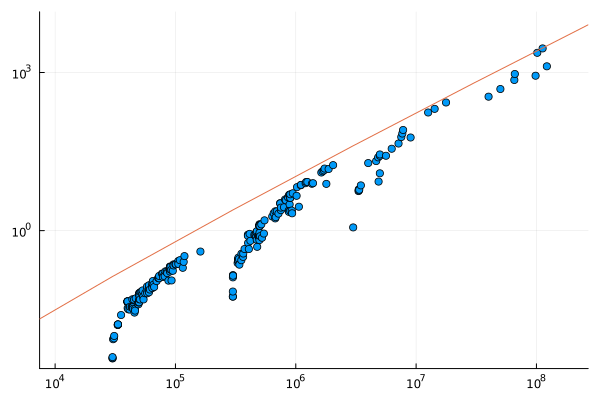

In [123]:
pdata = sort_nnz_w_time
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)

logmin = log10(nnzmin)-1
logmax = log10(nnzmax)+1
pmodelx = [10^i for i = logmin:logmax];
pmodely = [ 5e-8 * 10^i * i^3 for i = logmin:logmax];

plot!(pmodelx,pmodely,label="",xaxis =:log,xlims=[1e4,2e8],yaxis=:log)

# ac2 scaling on all 

In [181]:
datasets = [
    # unweighted chimera
    "uni_chimera_all.jl.split02merge02.n10000.h1.0.jld2",
    "uni_chimera_all.jl.split02merge02.n100000.h2.0.jld2",
    "uni_chimera_all.jl.split02merge02.n1000000.h4.0.jld2",
    "uni_chimera_all.jl.split02merge02.n10000000.h8.0.jld2",
    # weighted chimera
    "wted_chimera_nopetsc.jl.split02merge02.n10000.h1.0.jld2",
    "wted_chimera_nopetsc.jl.split02merge02.n100000.h2.0.jld2",
    "wted_chimera_nopetsc.jl.split02merge02.n1000000.h4.0.jld2",
    "wted_chimera_nopetsc.jl.split02merge02.n10000000.h8.0.jld2",
    # unweighted boundary chimera
    "uni_bndry_chimera_all.jl.split02merge02.n10000.h1.0.jld2",
    "uni_bndry_chimera_all.jl.split02merge02.n100000.h2.0.jld2",
    "uni_bndry_chimera_all.jl.split02merge02.n1000000.h4.0.jld2",
    "uni_bndry_chimera_all.jl.split02merge02.n10000000.h8.0.jld2",
    # weighted boundary chimera
    "wted_bndry_chimera_nopetsc.jl.split02merge02.n10000.h1.0.jld2",
    "wted_bndry_chimera_nopetsc.jl.split02merge02.n100000.h2.0.jld2",
    "wted_bndry_chimera_nopetsc.jl.split02merge02.n1000000.h4.0.jld2",
    "wted_bndry_chimera_nopetsc.jl.split02merge02.n10000000.h8.0.jld2",
    # max flow 
    "chimeraIPM_nopetsc.jl.split02merge02.jld2",
    "spielmanIPM_all.jl.split02merge02.jld2",
    # Sachdeva star 
    "sachdeva_star_all.jl.split02merge02.jld2",
    # SPE 
    "spe_all.jl.split02merge02.jld2",
    # uniform grid
    "uniform_grid_all.jl.split02merge02.jld2",
    # checkered grid (high contrast grid)
    "checkered_all.jl.split02merge02.jld2",
    # aniso grid 
    "aniso_all.jl.split02merge02.jld2",
    # weighted grid 
    "wgrid_all.jl.split02merge02.jld2",
    # SuiteSparse 
    "suitesparse_all.jl.split02merge02.jld2"
];

In [182]:
dic_all = Dict();
for ds in datasets
    dic = load_object(ds)
    dic_all = merge(vcat,dic_all, dic);
end

In [190]:
nnz_w_time = [ dic_all["ne"] dic_all["ac_tot"] ];
sort_nnz_w_time = sortrows(nnz_w_time,1);

In [191]:
nnz_w_time

1249×2 Matrix{Float64}:
  53364.0        0.0254362
  90000.0        0.046289
  35334.0        0.0134501
  60284.0        0.0248051
  90000.0        0.0371051
  46148.0        0.0192132
  30828.0        0.00687885
  41614.0        0.016151
  96292.0        0.0504169
  40536.0        0.0148308
  49832.0        0.0210681
  64238.0        0.0210044
  33150.0        0.0109189
      ⋮          
 760154.0        0.54979
 199200.0        0.0850949
   4257.0        0.00168586
    153.0        0.000175238
    420.0        0.000334978
 327680.0        0.12623
   3255.0        0.00152278
 542184.0        0.298217
   1473.0        0.000765085
      4.996e6    4.42448
   4617.0        0.00219917
      4.99599e6  4.96781

In [193]:
findall(nnz_w_time[:,1] .== 24 )

1-element Vector{Int64}:
 1221

In [196]:
nnz_w_time[1221,1], nnz_w_time[1221,2]

(24.0, 0.4973769187927246)

In [192]:
sort_nnz_w_time

1249×2 Matrix{Float64}:
   24.0           0.497377
   66.0           0.000208139
   66.0           0.00011611
   72.0           0.278529
  138.0           0.000181913
  153.0           0.000175238
  399.0           0.00039506
  420.0           0.000334978
  485.0           0.000355721
  817.0           0.00044179
 1074.0           0.00057292
 1083.0           0.000576019
 1473.0           0.000765085
    ⋮          
    2.16902e8   159.4
    2.16902e8    99.1762
    2.16902e8    96.2299
    2.16902e8    93.2577
    2.16902e8    93.2782
    2.16902e8    90.1095
    2.16902e8    90.0941
    2.16902e8    90.1829
    2.16902e8    89.5132
    2.16902e8    90.697
    2.16902e8    90.7236
    2.56001e8  1071.75

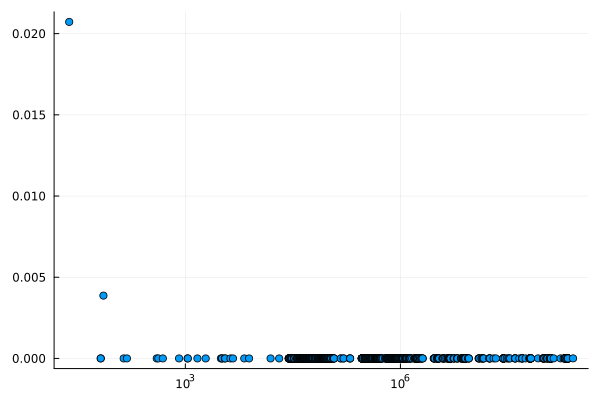

In [208]:
pdata = [ sort_nnz_w_time[:,1] sort_nnz_w_time[:,2]./sort_nnz_w_time[:,1] ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log)

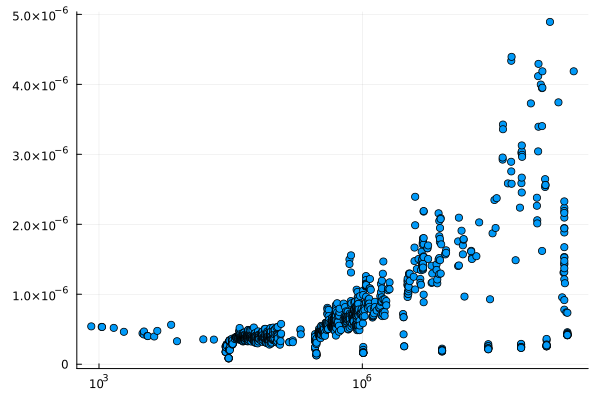

In [209]:
pdata = [ sort_nnz_w_time[10:end,1] sort_nnz_w_time[10:end,2]./sort_nnz_w_time[10:end,1] ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log)

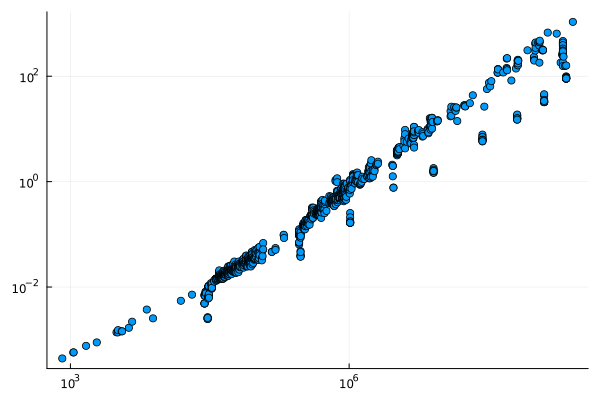

In [212]:
pdata = [ sort_nnz_w_time[10:end,1] sort_nnz_w_time[10:end,2] ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,yaxis=:log)

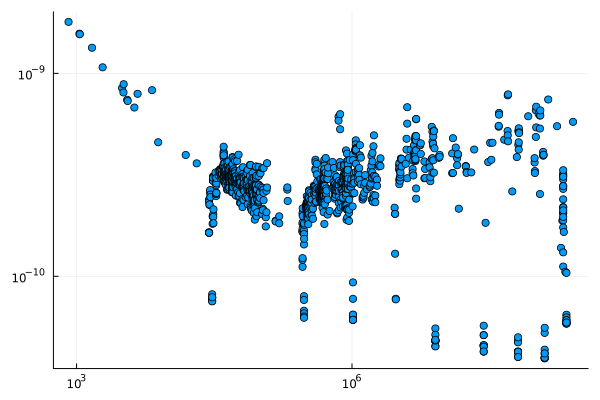

In [213]:
pdata = [ sort_nnz_w_time[10:end,1] sort_nnz_w_time[10:end,2]./((x->x*log(x)^3).(sort_nnz_w_time[10:end,1])) ]
scatter(pdata[:,1],pdata[:,2],label="",xaxis =:log,yaxis=:log)